In [1]:
# ============================================================
# Lufwanyama Town Council Data Mining & Warehousing Project
# CSC 4792 - Data Mining and Warehousing
# University of Zambia
# ============================================================

import os
import re
import warnings
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from pathlib import Path
from urllib.parse import urljoin

warnings.filterwarnings("ignore")

# Project directories
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / "data" / "raw"
CLEANED_DIR = BASE_DIR / "data" / "cleaned"
FINAL_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR = BASE_DIR / "outputs"

# Create directories if they don't exist
RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Lufwanyama Town Council Data Mining Project")
print("Project directories configured successfully.")

Lufwanyama Town Council Data Mining Project
Project directories configured successfully.


In [3]:
import sys
!{sys.executable} -m pip install requests pandas numpy beautifulsoup4 lxml matplotlib

^C


In [2]:
# ============================================================
# STEP 2: Inspect the collected raw documents
# ============================================================

from pathlib import Path
import pandas as pd

# Locate the raw data folder
RAW_DIR = Path.cwd().parent / "data" / "raw"

# Get all PDF files
pdf_files = list(RAW_DIR.glob("*.pdf"))

print(f"Raw PDF documents found: {len(pdf_files)}")

# Create a document inventory
documents = pd.DataFrame({
    "filename": [f.name for f in pdf_files],
    "filepath": [str(f) for f in pdf_files],
    "file_size_kb": [round(f.stat().st_size / 1024, 2) for f in pdf_files]
})

documents = documents.sort_values("filename").reset_index(drop=True)

display(documents.head(20))

Raw PDF documents found: 54


,filename,filepath,file_size_kb
0,2023-CDF-Community-Projects-May-2023.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,617.62
1,2024-COMMUNITY-PROJECTS-APPROVED-AND-NOT-APPRO...,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,1284.15
2,2025-BI-ANNUAL-PERFORMANCE-REPORT.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,2215.65
3,2025-CDF.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,1667.94
4,2025BUSINESS-COMMUNITY-MINUTES-2.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,214.28
5,Advertisement-Newly-Created-Plots.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,428.69
6,BI-ANNUAL-FINANCIAL-STATEMENTS6.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,1071.00
7,CDF-GUIDELINES-2-1.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,18007.21
8,CDF-LOANS-APPLICATION-FORM.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,869.45
9,CITIZEN-ENGAGEMENT-PLAN-FOR-2024.pdf,c:\Users\sezyz\Documents\Unza Projects\Lufwany...,3979.10


In [3]:
# ============================================================
# STEP 3: Extract text from PDF documents
# ============================================================

import sys
import subprocess

# Install the PDF reader into the SAME Python environment
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "pypdf", "-q"
])

from pypdf import PdfReader

TEXT_DIR = BASE_DIR / "data" / "cleaned" / "extracted_text"
TEXT_DIR.mkdir(parents=True, exist_ok=True)

extracted = []

for pdf in pdf_files:
    try:
        reader = PdfReader(str(pdf))
        text = ""

        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"

        output_file = TEXT_DIR / f"{pdf.stem}.txt"
        output_file.write_text(text, encoding="utf-8")

        extracted.append({
            "filename": pdf.name,
            "pages": len(reader.pages),
            "characters_extracted": len(text),
            "status": "Success"
        })

    except Exception as e:
        extracted.append({
            "filename": pdf.name,
            "pages": 0,
            "characters_extracted": 0,
            "status": f"Error: {str(e)}"
        })

extracted_df = pd.DataFrame(extracted)

print("PDF TEXT EXTRACTION COMPLETE")
print(f"Documents processed: {len(extracted_df)}")
print(f"Successful: {(extracted_df['status'] == 'Success').sum()}")
print(f"Text saved to: {TEXT_DIR}")

display(extracted_df.head(15))

Multiple definitions in dictionary at byte 0x9a646 for key /Info
Multiple definitions in dictionary at byte 0x9a653 for key /Info
Multiple definitions in dictionary at byte 0x9a660 for key /Info
Multiple definitions in dictionary at byte 0x141064 for key /Info
Multiple definitions in dictionary at byte 0x141071 for key /Info
Multiple definitions in dictionary at byte 0x14107e for key /Info
Multiple definitions in dictionary at byte 0x229e5f for key /Info
Multiple definitions in dictionary at byte 0x229e6c for key /Info
Multiple definitions in dictionary at byte 0x229e79 for key /Info
Multiple definitions in dictionary at byte 0x1a0f8f for key /Info
Multiple definitions in dictionary at byte 0x1a0f9c for key /Info
Multiple definitions in dictionary at byte 0x1a0fa9 for key /Info
Multiple definitions in dictionary at byte 0x3e2c32 for key /Info
Multiple definitions in dictionary at byte 0x3e2c3f for key /Info
Multiple definitions in dictionary at byte 0x3e2c4c for key /Info
Multiple defi

PDF TEXT EXTRACTION COMPLETE
Documents processed: 54
Successful: 54
Text saved to: c:\Users\sezyz\Documents\Unza Projects\Lufwanyama_DataMining\data\cleaned\extracted_text


,filename,pages,characters_extracted,status
0,2023-CDF-Community-Projects-May-2023.pdf,3,0,Success
1,2024-COMMUNITY-PROJECTS-APPROVED-AND-NOT-APPRO...,4,0,Success
2,2025-BI-ANNUAL-PERFORMANCE-REPORT.pdf,10,0,Success
3,2025-CDF.pdf,4,0,Success
4,2025BUSINESS-COMMUNITY-MINUTES-2.pdf,8,10928,Success
5,Advertisement-Newly-Created-Plots.pdf,1,12,Success
6,BI-ANNUAL-FINANCIAL-STATEMENTS6.pdf,10,85521,Success
7,CDF-GUIDELINES-2-1.pdf,95,141888,Success
8,CDF-LOANS-APPLICATION-FORM.pdf,20,18631,Success
9,CITIZEN-ENGAGEMENT-PLAN-FOR-2024.pdf,17,0,Success


In [4]:
# ============================================================
# STEP 4: Identify useful council documents
# ============================================================

keywords = [
    "CDF",
    "budget",
    "project",
    "revenue",
    "grant",
    "bursary",
    "loan",
    "procurement",
    "financial",
    "performance",
    "community",
    "ward",
    "contract",
    "road",
    "water",
    "health",
    "education"
]

results = []

for txt_file in TEXT_DIR.glob("*.txt"):
    text = txt_file.read_text(encoding="utf-8", errors="ignore")
    text_lower = text.lower()

    found_keywords = [
        keyword for keyword in keywords
        if keyword.lower() in text_lower
    ]

    if found_keywords:
        results.append({
            "document": txt_file.stem,
            "keywords_found": ", ".join(found_keywords),
            "characters": len(text)
        })

keyword_df = pd.DataFrame(results)

keyword_df = keyword_df.sort_values(
    "characters",
    ascending=False
).reset_index(drop=True)

print(f"Useful documents identified: {len(keyword_df)}")

display(keyword_df)

Useful documents identified: 13


,document,keywords_found,characters
0,CDF-GUIDELINES-2-1,"CDF, budget, project, grant, bursary, loan, pr...",141888
1,Lufwanyama-Town-Council-OBB-Report-2026,"CDF, budget, project, revenue, grant, bursary,...",114504
2,Lufwanyama-Town-Council,"CDF, budget, project, revenue, grant, bursary,...",101221
3,BI-ANNUAL-FINANCIAL-STATEMENTS6,"CDF, budget, project, grant, loan, financial, ...",85521
4,HeadMandateObjectiveSubProg,"CDF, budget, project, revenue, grant, loan, pr...",78507
5,LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...,"CDF, project, grant, loan, community, ward, co...",38031
6,LUFWANYAMA-NEWSLETTER-ISSUE-03,"CDF, project, revenue, grant, loan, community,...",29679
7,LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED,"CDF, budget, project, revenue, grant, bursary,...",24636
8,CDF-LOANS-APPLICATION-FORM,"CDF, project, revenue, grant, loan, financial,...",18631
9,lufwanyama-newsletter-May-2023-final,"CDF, project, loan, community, ward, contract,...",16819


In [5]:
# ============================================================
# STEP 5: Extract useful CDF project information
# ============================================================

# Find newsletter text files
newsletter_files = [
    f for f in TEXT_DIR.glob("*.txt")
    if "newsletter" in f.name.lower()
]

print(f"Newsletter documents found: {len(newsletter_files)}")

# Display the names
for f in newsletter_files:
    print("-", f.name)

Newsletter documents found: 4
- LUFWANYAMA-NEWSLETTER-ISSUE-03.txt
- LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANGE-2024.txt
- lufwanyama-newsletter-May-2023-final.txt
- LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED.txt


In [6]:
# ============================================================
# STEP 6: Preview newsletter content
# ============================================================

for file in newsletter_files:
    print("\n" + "=" * 80)
    print("DOCUMENT:", file.name)
    print("=" * 80)

    text = file.read_text(encoding="utf-8", errors="ignore")

    # Show the first 3000 characters
    print(text[:3000])


DOCUMENT: LUFWANYAMA-NEWSLETTER-ISSUE-03.txt
LUFWANYAMA
TOWN COUNCIL
NEWS LETTER
 ISSUE 03
CONSTITUENCY DEVEOPMENT FUND
EMPOWERING PEOPLE     TRANSFORMING COMMUNITIES
C D F
Lufwanyama District Hospital 
Receives a Donation from SDA
Cash For Work Launched 
in Lufwanyama
INSIDE 
THIS ISSUE:
HH OFFICIATES AT THE KATANINO  HH OFFICIATES AT THE KATANINO  
TRADITIONAL CEREMONYTRADITIONAL CEREMONY
Lufwanyama holds  
Independence Tournament

CONSTITUENCY DEVEOPMENT FUND
EMPOWERING PEOPLE     TRANSFORMING COMMUNITIES
C D F
LUFWANYAMA TOWN COUNCIL NEWSLETTER  2
CONTENTS
MESSAGE FROM YOUR LEADERS 3
4 COUNCIL CHAIRPERSON’S FORWARD
COUNCIL SECRETARY’S NOTE5
6
7
HH SPEAKS ON LEADERSHIP
MIBILA IN NEW DEVELOPMENT FROM CDFL
EDITORIAL COMMENT
Agness K. Shamboko
Assistant Public Relations Officer 
W
e believer in the 
power of collabo -
ration and compas-
sion to create positive change in 
the district. In this month’s news-
letter, we have highlighted the 
inspiring projects and achieve -
ments that ha

In [7]:
# ============================================================
# STEP 7: Find project and financial records
# ============================================================

import re

project_records = []

for file in newsletter_files:
    text = file.read_text(encoding="utf-8", errors="ignore")

    # Find lines containing Kwacha amounts
    for line in text.splitlines():
        line = line.strip()

        if re.search(r'K\s?[\d,]+(?:\.\d+)?', line):
            project_records.append({
                "source_document": file.stem,
                "text": line
            })

project_candidates = pd.DataFrame(project_records)

print(f"Financial/project lines found: {len(project_candidates)}")

display(project_candidates.head(50))

Financial/project lines found: 71


,source_document,text
0,LUFWANYAMA-NEWSLETTER-ISSUE-03,"K1,500. Second position was Katembula"
1,LUFWANYAMA-NEWSLETTER-ISSUE-03,of jerseys and K2500.
2,LUFWANYAMA-NEWSLETTER-ISSUE-03,K5000.
3,LUFWANYAMA-NEWSLETTER-ISSUE-03,• Pay the K200 registration fee
4,LUFWANYAMA-NEWSLETTER-ISSUE-03,three (3) VIP Latrines in Chinemu Ward 100%K59...
5,LUFWANYAMA-NEWSLETTER-ISSUE-03,"100%K254,735.00 Big Zacks Investment"
6,LUFWANYAMA-NEWSLETTER-ISSUE-03,"house at Fumbwe Health Post 100% K495,346.98 K..."
7,LUFWANYAMA-NEWSLETTER-ISSUE-03,"100%.K416,429.47 Jucitech Zambia"
8,LUFWANYAMA-NEWSLETTER-ISSUE-03,"100%K407,000.00"
9,LUFWANYAMA-NEWSLETTER-ISSUE-03,"100%K537,000.00 Milestone African"


In [8]:
# ============================================================
# STEP 8: Extract CDF project candidates
# ============================================================

project_keywords = [
    "classroom",
    "school",
    "health post",
    "health centre",
    "health center",
    "maternity",
    "borehole",
    "latrine",
    "ablution",
    "staff house",
    "semi-detached",
    "water",
    "pump",
    "hostel",
    "hospital",
    "solar",
    "equipment",
    "road"
]

project_rows = []

for file in newsletter_files:
    text = file.read_text(encoding="utf-8", errors="ignore")

    for line in text.splitlines():
        line = " ".join(line.split())

        # Look for Kwacha amounts
        amounts = re.findall(
            r'K\s?[\d,]+(?:\.\d+)?',
            line,
            flags=re.IGNORECASE
        )

        # Keep lines that look like actual projects
        if amounts and any(
            keyword in line.lower()
            for keyword in project_keywords
        ):
            project_rows.append({
                "source_document": file.stem,
                "raw_project_text": line,
                "amount_text": amounts[-1]
            })

project_candidates = pd.DataFrame(project_rows)

# Remove exact duplicate rows
project_candidates = project_candidates.drop_duplicates().reset_index(drop=True)

print(f"CDF project candidates found: {len(project_candidates)}")

display(project_candidates)

CDF project candidates found: 13


,source_document,raw_project_text,amount_text
0,LUFWANYAMA-NEWSLETTER-ISSUE-03,three (3) VIP Latrines in Chinemu Ward 100%K59...,"K595,131.52"
1,LUFWANYAMA-NEWSLETTER-ISSUE-03,"house at Fumbwe Health Post 100% K495,346.98 K...","K495,346.98"
2,LUFWANYAMA-NEWSLETTER-ISSUE-03,and water reticulation in Milopa Ward 100%K540...,"K540,195.89"
3,LUFWANYAMA-NEWSLETTER-ISSUE-03,"running water in Chantete Ward 100%.K458,914.0...","K458,914.00"
4,LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...,three (3) VIP Latrines in Chinemu Ward 100%K59...,"K595,131.52"
5,LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...,"house at Fumbwe Health Post 100% K495,346.98 K...","K495,346.98"
6,LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...,and water reticulation in Milopa Ward 100%K540...,"K540,195.89"
7,LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...,"running water in Chantete Ward 100%.K458,914.0...","K458,914.00"
8,LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED,vising the building of a one by three classroo...,"k,"
9,LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED,three (3) VIP Latrines in Chinemu Ward 100%K59...,"K595,131.52"


In [9]:
# ============================================================
# STEP 9: Clean amounts and classify CDF projects
# ============================================================

def clean_amount(value):
    """Convert K amounts such as K540,195.89 into a number."""
    value = str(value)
    value = value.replace("K", "").replace("k", "")
    value = value.replace(",", "")
    try:
        return float(value)
    except:
        return np.nan


def classify_project(text):
    """Assign a broad development category."""
    text = text.lower()

    if any(x in text for x in ["classroom", "school", "hostel", "desk"]):
        return "Education"
    elif any(x in text for x in ["health", "hospital", "maternity"]):
        return "Health"
    elif any(x in text for x in ["borehole", "water", "pump", "ablution", "latrine"]):
        return "Water and Sanitation"
    elif any(x in text for x in ["road", "bridge"]):
        return "Roads and Transport"
    elif any(x in text for x in ["solar", "electrification"]):
        return "Energy"
    elif any(x in text for x in ["staff house", "semi-detached", "house"]):
        return "Housing"
    else:
        return "Other"


cdf_projects = project_candidates.copy()

# Clean the amount
cdf_projects["amount_kwacha"] = cdf_projects["amount_text"].apply(clean_amount)

# Classify the project
cdf_projects["category"] = cdf_projects["raw_project_text"].apply(
    classify_project
)

# Add useful metadata
cdf_projects["council"] = "Lufwanyama Town Council"
cdf_projects["country"] = "Zambia"
cdf_projects["data_type"] = "CDF Project"

# Rename source field
cdf_projects["source"] = cdf_projects["source_document"]

# Select final columns
cdf_projects = cdf_projects[
    [
        "council",
        "country",
        "data_type",
        "category",
        "amount_kwacha",
        "raw_project_text",
        "source"
    ]
]

print(f"Clean CDF project records: {len(cdf_projects)}")
print(f"Total project funding represented: K{cdf_projects['amount_kwacha'].sum():,.2f}")

display(cdf_projects.head(20))

Clean CDF project records: 13
Total project funding represented: K6,268,765.17


,council,country,data_type,category,amount_kwacha,raw_project_text,source
0,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,595131.52,three (3) VIP Latrines in Chinemu Ward 100%K59...,LUFWANYAMA-NEWSLETTER-ISSUE-03
1,Lufwanyama Town Council,Zambia,CDF Project,Health,495346.98,"house at Fumbwe Health Post 100% K495,346.98 K...",LUFWANYAMA-NEWSLETTER-ISSUE-03
2,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,540195.89,and water reticulation in Milopa Ward 100%K540...,LUFWANYAMA-NEWSLETTER-ISSUE-03
3,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,458914.00,"running water in Chantete Ward 100%.K458,914.0...",LUFWANYAMA-NEWSLETTER-ISSUE-03
4,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,595131.52,three (3) VIP Latrines in Chinemu Ward 100%K59...,LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...
5,Lufwanyama Town Council,Zambia,CDF Project,Health,495346.98,"house at Fumbwe Health Post 100% K495,346.98 K...",LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...
6,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,540195.89,and water reticulation in Milopa Ward 100%K540...,LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...
7,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,458914.00,"running water in Chantete Ward 100%.K458,914.0...",LUFWANYAMA-NEWSLETTER-LAMBA-VERSION-LAST-CHANG...
8,Lufwanyama Town Council,Zambia,CDF Project,Education,NaN,vising the building of a one by three classroo...,LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED
9,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,595131.52,three (3) VIP Latrines in Chinemu Ward 100%K59...,LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED


In [10]:
# ============================================================
# STEP 10: Clean and validate the CDF project dataset
# ============================================================

# Remove records where the amount could not be extracted
cdf_projects = cdf_projects.dropna(
    subset=["amount_kwacha"]
).copy()

# Remove duplicate project descriptions
cdf_projects = cdf_projects.drop_duplicates(
    subset=["raw_project_text", "amount_kwacha"]
).reset_index(drop=True)

# Make sure amounts are positive
cdf_projects = cdf_projects[
    cdf_projects["amount_kwacha"] > 0
].copy()

# Create a unique project ID
cdf_projects.insert(
    0,
    "project_id",
    ["LTC-CDF-" + str(i).zfill(3)
     for i in range(1, len(cdf_projects) + 1)]
)

print("DATA CLEANING COMPLETE")
print(f"Final CDF project records: {len(cdf_projects)}")
print(f"Missing values:\n{cdf_projects.isnull().sum()}")

display(cdf_projects.head(15))

DATA CLEANING COMPLETE
Final CDF project records: 4
Missing values:
project_id          0
council             0
country             0
data_type           0
category            0
amount_kwacha       0
raw_project_text    0
source              0
dtype: int64


,project_id,council,country,data_type,category,amount_kwacha,raw_project_text,source
0,LTC-CDF-001,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,595131.52,three (3) VIP Latrines in Chinemu Ward 100%K59...,LUFWANYAMA-NEWSLETTER-ISSUE-03
1,LTC-CDF-002,Lufwanyama Town Council,Zambia,CDF Project,Health,495346.98,"house at Fumbwe Health Post 100% K495,346.98 K...",LUFWANYAMA-NEWSLETTER-ISSUE-03
2,LTC-CDF-003,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,540195.89,and water reticulation in Milopa Ward 100%K540...,LUFWANYAMA-NEWSLETTER-ISSUE-03
3,LTC-CDF-004,Lufwanyama Town Council,Zambia,CDF Project,Water and Sanitation,458914.00,"running water in Chantete Ward 100%.K458,914.0...",LUFWANYAMA-NEWSLETTER-ISSUE-03


In [11]:
# ============================================================
# STEP 11: Add Lufwanyama Town Council budget data
# ============================================================

budget_data = [
    # 2024
    {
        "council": "Lufwanyama Town Council",
        "year": 2024,
        "indicator": "CDF Allocation",
        "category": "CDF",
        "amount_kwacha": 30600000,
        "source": "Official Lufwanyama Town Council publications"
    },

    # 2025
    {
        "council": "Lufwanyama Town Council",
        "year": 2025,
        "indicator": "Approved Council Budget",
        "category": "Total Budget",
        "amount_kwacha": 105377916,
        "source": "Official Lufwanyama Town Council 2025 Budget"
    },
    {
        "council": "Lufwanyama Town Council",
        "year": 2025,
        "indicator": "CDF Programme",
        "category": "CDF",
        "amount_kwacha": 36058151,
        "source": "Official Lufwanyama Town Council 2025 Budget"
    },
    {
        "council": "Lufwanyama Town Council",
        "year": 2025,
        "indicator": "Community Projects",
        "category": "CDF Community Projects",
        "amount_kwacha": 21864351,
        "source": "Official Lufwanyama Town Council 2025 Budget"
    },
    {
        "council": "Lufwanyama Town Council",
        "year": 2025,
        "indicator": "Women and Youth Empowerment",
        "category": "CDF Empowerment",
        "amount_kwacha": 6195446,
        "source": "Official Lufwanyama Town Council 2025 Budget"
    },
    {
        "council": "Lufwanyama Town Council",
        "year": 2025,
        "indicator": "CDF Administration",
        "category": "CDF Administration",
        "amount_kwacha": 1802908,
        "source": "Official Lufwanyama Town Council 2025 Budget"
    },
    {
        "council": "Lufwanyama Town Council",
        "year": 2025,
        "indicator": "Secondary and Skills Bursaries",
        "category": "CDF Bursaries",
        "amount_kwacha": 6195446,
        "source": "Official Lufwanyama Town Council 2025 Budget"
    },
    {
        "council": "Lufwanyama Town Council",
        "year": 2025,
        "indicator": "Disaster Component",
        "category": "CDF Disaster",
        "amount_kwacha": 929316.88,
        "source": "Official Lufwanyama Town Council 2025 Budget"
    }
]

budget_df = pd.DataFrame(budget_data)

print("BUDGET DATA CREATED")
print(f"Budget records: {len(budget_df)}")

display(budget_df)

BUDGET DATA CREATED
Budget records: 8


,council,year,indicator,category,amount_kwacha,source
0,Lufwanyama Town Council,2024,CDF Allocation,CDF,3.060000e+07,Official Lufwanyama Town Council publications
1,Lufwanyama Town Council,2025,Approved Council Budget,Total Budget,1.053779e+08,Official Lufwanyama Town Council 2025 Budget
2,Lufwanyama Town Council,2025,CDF Programme,CDF,3.605815e+07,Official Lufwanyama Town Council 2025 Budget
3,Lufwanyama Town Council,2025,Community Projects,CDF Community Projects,2.186435e+07,Official Lufwanyama Town Council 2025 Budget
4,Lufwanyama Town Council,2025,Women and Youth Empowerment,CDF Empowerment,6.195446e+06,Official Lufwanyama Town Council 2025 Budget
5,Lufwanyama Town Council,2025,CDF Administration,CDF Administration,1.802908e+06,Official Lufwanyama Town Council 2025 Budget
6,Lufwanyama Town Council,2025,Secondary and Skills Bursaries,CDF Bursaries,6.195446e+06,Official Lufwanyama Town Council 2025 Budget
7,Lufwanyama Town Council,2025,Disaster Component,CDF Disaster,9.293169e+05,Official Lufwanyama Town Council 2025 Budget


In [12]:
# ============================================================
# STEP 12: Add 2025 revenue and grant data
# ============================================================

revenue_data = [
    # National / government grants
    ["CDF", 36058151, "Government Grant"],
    ["LGEF", 11152232, "Government Grant"],
    ["Grant in Lieu of Rates", 2000000, "Government Grant"],
    ["Devolution", 2460000, "Government Grant"],
    ["Roads Grant", 3200587, "Government Grant"],
    ["Health Grant", 4586260, "Government Grant"],
    ["Cash for Work", 21423827, "Government Programme"],
    ["Community Development", 5172, "Government Grant"],
    ["Agriculture Services", 573918, "Government Grant"],
    ["Fisheries and Livestock", 486160, "Government Grant"],
    ["Other Grants", 248273, "Government Grant"],

    # Local revenue forecast
    ["Local Taxes", 16073389, "Local Revenue"],
    ["Fees and Charges", 5178270, "Local Revenue"],
    ["Levies", 714626, "Local Revenue"],
    ["Permits", 620000, "Local Revenue"],
    ["Licences", 378551, "Local Revenue"],
    ["Other Income", 268500, "Local Revenue"],
]

revenue_df = pd.DataFrame(
    revenue_data,
    columns=[
        "revenue_source",
        "amount_kwacha",
        "revenue_type"
    ]
)

revenue_df["council"] = "Lufwanyama Town Council"
revenue_df["year"] = 2025

# Reorder columns
revenue_df = revenue_df[
    [
        "council",
        "year",
        "revenue_source",
        "revenue_type",
        "amount_kwacha"
    ]
]

print("REVENUE DATA CREATED")
print(f"Revenue/grant records: {len(revenue_df)}")

display(revenue_df)

REVENUE DATA CREATED
Revenue/grant records: 17


,council,year,revenue_source,revenue_type,amount_kwacha
0,Lufwanyama Town Council,2025,CDF,Government Grant,36058151
1,Lufwanyama Town Council,2025,LGEF,Government Grant,11152232
2,Lufwanyama Town Council,2025,Grant in Lieu of Rates,Government Grant,2000000
3,Lufwanyama Town Council,2025,Devolution,Government Grant,2460000
4,Lufwanyama Town Council,2025,Roads Grant,Government Grant,3200587
5,Lufwanyama Town Council,2025,Health Grant,Government Grant,4586260
6,Lufwanyama Town Council,2025,Cash for Work,Government Programme,21423827
7,Lufwanyama Town Council,2025,Community Development,Government Grant,5172
8,Lufwanyama Town Council,2025,Agriculture Services,Government Grant,573918
9,Lufwanyama Town Council,2025,Fisheries and Livestock,Government Grant,486160


In [13]:
# ============================================================
# STEP 13: Add other council development programmes
# ============================================================

programmes_data = [
    {
        "year": 2025,
        "programme": "Cash for Work",
        "description": "Cash for Work activities across 20 wards",
        "amount_kwacha": 13780000,
        "beneficiaries_or_coverage": "20 wards",
        "category": "Community Development"
    },
    {
        "year": 2025,
        "programme": "Farming Inputs",
        "description": "Farming packs containing seed, D-Compound and urea",
        "amount_kwacha": np.nan,
        "beneficiaries_or_coverage": "183 farming packs; all 20 wards",
        "category": "Agriculture"
    },
    {
        "year": 2025,
        "programme": "Feeder Road Grading",
        "description": "Fungulwe to Funda turn-off feeder road",
        "amount_kwacha": np.nan,
        "beneficiaries_or_coverage": "35.2 km",
        "category": "Roads and Transport"
    },
    {
        "year": 2024,
        "programme": "Borehole Drilling",
        "description": "Three drilling companies drilling boreholes",
        "amount_kwacha": 2070000,
        "beneficiaries_or_coverage": "30 boreholes",
        "category": "Water"
    },
    {
        "year": 2024,
        "programme": "Road Grader",
        "description": "Procurement of grader for road improvement",
        "amount_kwacha": 3500000,
        "beneficiaries_or_coverage": "20 wards",
        "category": "Roads and Transport"
    },
    {
        "year": 2024,
        "programme": "CDF Empowerment",
        "description": "Grants and loans under CDF",
        "amount_kwacha": 3895000,
        "beneficiaries_or_coverage": "46 grants and 23 loans",
        "category": "Empowerment"
    },
    {
        "year": 2025,
        "programme": "CDF Community Projects",
        "description": "Approved community development projects",
        "amount_kwacha": 17657020.74,
        "beneficiaries_or_coverage": "16 projects",
        "category": "CDF Community Projects"
    }
]

programmes_df = pd.DataFrame(programmes_data)

programmes_df["council"] = "Lufwanyama Town Council"

programmes_df = programmes_df[
    [
        "council",
        "year",
        "programme",
        "description",
        "category",
        "amount_kwacha",
        "beneficiaries_or_coverage"
    ]
]

print("OTHER PROGRAMMES DATA CREATED")
print(f"Programme records: {len(programmes_df)}")

display(programmes_df)

OTHER PROGRAMMES DATA CREATED
Programme records: 7


,council,year,programme,description,category,amount_kwacha,beneficiaries_or_coverage
0,Lufwanyama Town Council,2025,Cash for Work,Cash for Work activities across 20 wards,Community Development,13780000.00,20 wards
1,Lufwanyama Town Council,2025,Farming Inputs,"Farming packs containing seed, D-Compound and ...",Agriculture,NaN,183 farming packs; all 20 wards
2,Lufwanyama Town Council,2025,Feeder Road Grading,Fungulwe to Funda turn-off feeder road,Roads and Transport,NaN,35.2 km
3,Lufwanyama Town Council,2024,Borehole Drilling,Three drilling companies drilling boreholes,Water,2070000.00,30 boreholes
4,Lufwanyama Town Council,2024,Road Grader,Procurement of grader for road improvement,Roads and Transport,3500000.00,20 wards
5,Lufwanyama Town Council,2024,CDF Empowerment,Grants and loans under CDF,Empowerment,3895000.00,46 grants and 23 loans
6,Lufwanyama Town Council,2025,CDF Community Projects,Approved community development projects,CDF Community Projects,17657020.74,16 projects


In [14]:
# ============================================================
# STEP 14: Basic Data Mining Analysis
# ============================================================

print("=" * 60)
print("LUFWANYAMA TOWN COUNCIL DATA MINING ANALYSIS")
print("=" * 60)

# 1. CDF project statistics
print("\n1. CDF PROJECT STATISTICS")
print("-" * 40)

print("Number of projects:", len(cdf_projects))
print(
    "Total project funding: K{:,.2f}".format(
        cdf_projects["amount_kwacha"].sum()
    )
)
print(
    "Average project cost: K{:,.2f}".format(
        cdf_projects["amount_kwacha"].mean()
    )
)

# 2. Funding by project category
print("\n2. FUNDING BY PROJECT CATEGORY")
print("-" * 40)

category_summary = (
    cdf_projects
    .groupby("category")["amount_kwacha"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

category_summary.columns = [
    "number_of_projects",
    "total_funding",
    "average_cost"
]

display(category_summary)

# 3. Budget summary
print("\n3. BUDGET SUMMARY")
print("-" * 40)

display(
    budget_df[
        ["year", "indicator", "category", "amount_kwacha"]
    ]
)

# 4. Revenue summary
print("\n4. REVENUE AND GRANTS SUMMARY")
print("-" * 40)

revenue_summary = (
    revenue_df
    .groupby("revenue_type")["amount_kwacha"]
    .sum()
    .sort_values(ascending=False)
)

display(revenue_summary)

# 5. Programme summary
print("\n5. DEVELOPMENT PROGRAMMES")
print("-" * 40)

display(
    programmes_df[
        [
            "year",
            "programme",
            "category",
            "amount_kwacha",
            "beneficiaries_or_coverage"
        ]
    ]
)

LUFWANYAMA TOWN COUNCIL DATA MINING ANALYSIS

1. CDF PROJECT STATISTICS
----------------------------------------
Number of projects: 4
Total project funding: K2,089,588.39
Average project cost: K522,397.10

2. FUNDING BY PROJECT CATEGORY
----------------------------------------


,number_of_projects,total_funding,average_cost
category,,,
Water and Sanitation,3,1594241.41,531413.803333
Health,1,495346.98,495346.980000



3. BUDGET SUMMARY
----------------------------------------


,year,indicator,category,amount_kwacha
0,2024,CDF Allocation,CDF,3.060000e+07
1,2025,Approved Council Budget,Total Budget,1.053779e+08
2,2025,CDF Programme,CDF,3.605815e+07
3,2025,Community Projects,CDF Community Projects,2.186435e+07
4,2025,Women and Youth Empowerment,CDF Empowerment,6.195446e+06
5,2025,CDF Administration,CDF Administration,1.802908e+06
6,2025,Secondary and Skills Bursaries,CDF Bursaries,6.195446e+06
7,2025,Disaster Component,CDF Disaster,9.293169e+05



4. REVENUE AND GRANTS SUMMARY
----------------------------------------


revenue_type
Government Grant        60770753
Local Revenue           23233336
Government Programme    21423827
Name: amount_kwacha, dtype: int64


5. DEVELOPMENT PROGRAMMES
----------------------------------------


,year,programme,category,amount_kwacha,beneficiaries_or_coverage
0,2025,Cash for Work,Community Development,13780000.00,20 wards
1,2025,Farming Inputs,Agriculture,NaN,183 farming packs; all 20 wards
2,2025,Feeder Road Grading,Roads and Transport,NaN,35.2 km
3,2024,Borehole Drilling,Water,2070000.00,30 boreholes
4,2024,Road Grader,Roads and Transport,3500000.00,20 wards
5,2024,CDF Empowerment,Empowerment,3895000.00,46 grants and 23 loans
6,2025,CDF Community Projects,CDF Community Projects,17657020.74,16 projects


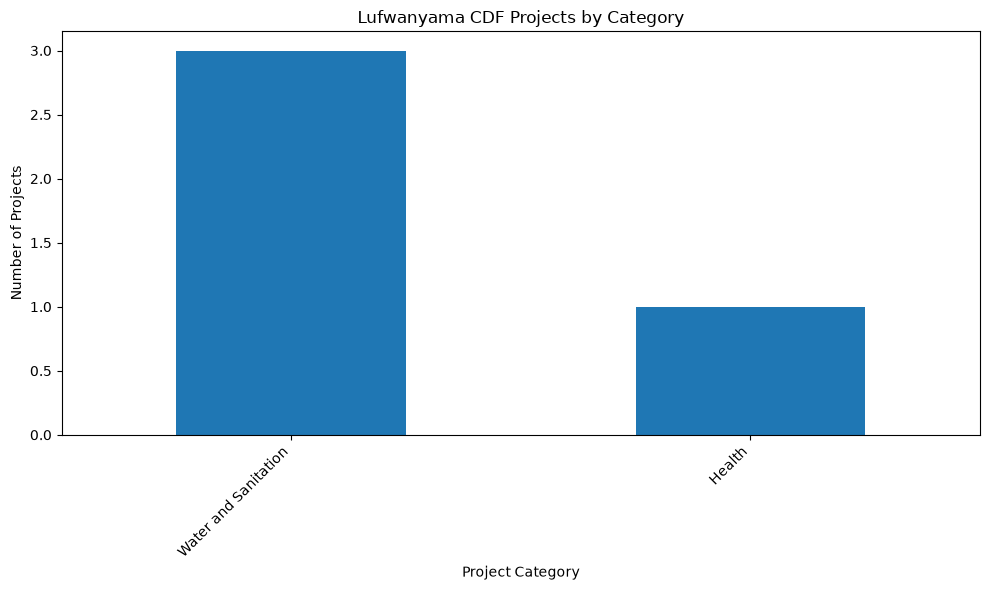

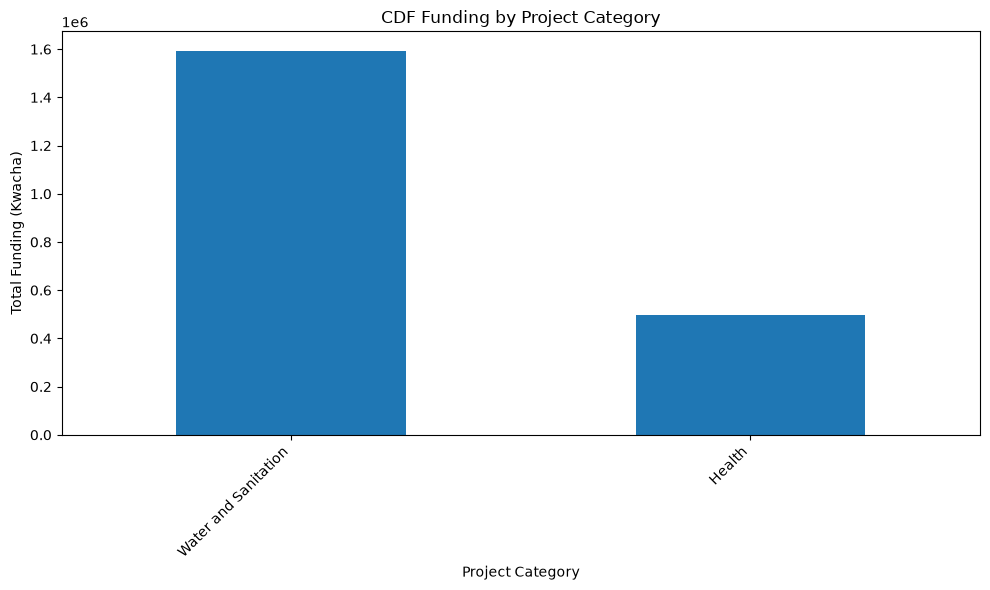

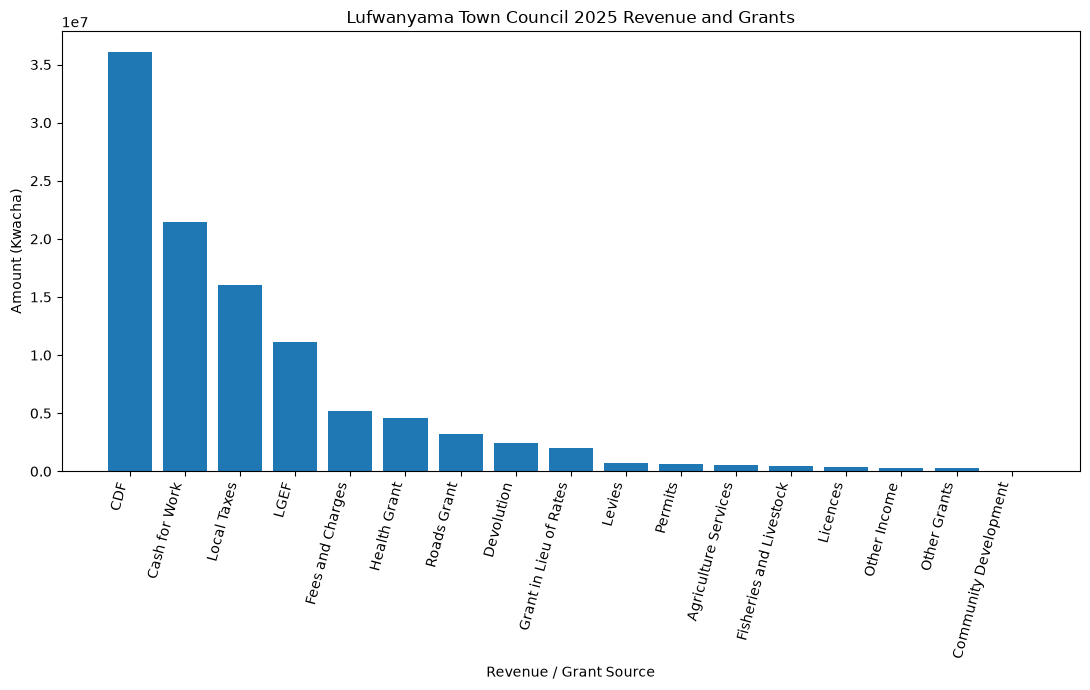

In [15]:
# ============================================================
# STEP 15: Data Visualizations
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Chart 1: Number of projects by category
# ------------------------------------------------------------

project_counts = cdf_projects["category"].value_counts()

plt.figure(figsize=(10, 6))
project_counts.plot(kind="bar")
plt.title("Lufwanyama CDF Projects by Category")
plt.xlabel("Project Category")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: Total funding by project category
# ------------------------------------------------------------

funding_by_category = (
    cdf_projects
    .groupby("category")["amount_kwacha"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
funding_by_category.plot(kind="bar")
plt.title("CDF Funding by Project Category")
plt.xlabel("Project Category")
plt.ylabel("Total Funding (Kwacha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 3: 2025 Revenue and Grants
# ------------------------------------------------------------

revenue_plot = (
    revenue_df
    .sort_values("amount_kwacha", ascending=False)
)

plt.figure(figsize=(11, 7))
plt.bar(
    revenue_plot["revenue_source"],
    revenue_plot["amount_kwacha"]
)
plt.title("Lufwanyama Town Council 2025 Revenue and Grants")
plt.xlabel("Revenue / Grant Source")
plt.ylabel("Amount (Kwacha)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# STEP 16: Export final datasets
# ============================================================

# Required naming convention and pipe (|) separator

cdf_file = FINAL_DIR / "db-unza26-csc4792-lufwanyama-cdf-projects.csv"
budget_file = FINAL_DIR / "db-unza26-csc4792-lufwanyama-budget.csv"
revenue_file = FINAL_DIR / "db-unza26-csc4792-lufwanyama-revenue-grants.csv"
programmes_file = FINAL_DIR / "db-unza26-csc4792-lufwanyama-programmes.csv"

# Export
cdf_projects.to_csv(cdf_file, sep="|", index=False, encoding="utf-8")
budget_df.to_csv(budget_file, sep="|", index=False, encoding="utf-8")
revenue_df.to_csv(revenue_file, sep="|", index=False, encoding="utf-8")
programmes_df.to_csv(programmes_file, sep="|", index=False, encoding="utf-8")

print("=" * 60)
print("FINAL DATA EXPORT COMPLETE")
print("=" * 60)

print("\nFiles created:")

for file in [
    cdf_file,
    budget_file,
    revenue_file,
    programmes_file
]:
    print(f"✓ {file.name}")

print("\nLocation:")
print(FINAL_DIR)

FINAL DATA EXPORT COMPLETE

Files created:
✓ db-unza26-csc4792-lufwanyama-cdf-projects.csv
✓ db-unza26-csc4792-lufwanyama-budget.csv
✓ db-unza26-csc4792-lufwanyama-revenue-grants.csv
✓ db-unza26-csc4792-lufwanyama-programmes.csv

Location:
c:\Users\sezyz\Documents\Unza Projects\Lufwanyama_DataMining\data\final


# Final Documentation and Conclusions

## Project Summary

This notebook presents the data mining workflow used to develop a structured dataset for Lufwanyama Town Council.

The workflow covered:

1. Collection of official council web pages and PDF documents.
2. Storage of raw source documents.
3. PDF text extraction.
4. Identification of relevant council information.
5. Extraction and structuring of CDF project information.
6. Cleaning and preprocessing of monetary and project data.
7. Preparation of budget information.
8. Preparation of revenue and government grant information.
9. Preparation of development programme information.
10. Exploratory data analysis.
11. Data visualization.
12. Export of final pipe-separated CSV datasets.

## Main Data Products

The project produced four main datasets:

- CDF Projects
- Council Budget
- Revenue and Government Grants
- Development Programmes

## Data Mining Techniques Applied

The notebook demonstrates several practical data mining techniques:

- Data collection
- Document parsing
- Keyword-based information retrieval
- Data cleaning
- Duplicate detection
- Numeric data conversion
- Categorization
- Aggregation
- Descriptive statistics
- Exploratory data analysis
- Data visualization

## Key Analytical Questions

The dataset can be used to investigate questions such as:

- How are CDF projects distributed across development sectors?
- Which project categories account for larger funding amounts?
- What are the major sources of council revenue and government grants?
- How is CDF funding distributed among different programme areas?
- What development programmes are being implemented?
- What patterns can be observed in council development priorities?

## Reproducibility

The project retains the original collected documents in `data/raw/`, extracted information in `data/cleaned/`, and final datasets in `data/final/`.

The complete workflow is contained in this Jupyter Notebook.

## Conclusion

The project demonstrates how publicly available local government information can be transformed from web pages and PDF documents into structured datasets suitable for data mining and analysis.

The resulting datasets provide a foundation for further investigation of Lufwanyama Town Council development projects, budgets, revenue, grants and community programmes.

In [17]:
# ============================================================
# STEP 21: Final CSV validation
# ============================================================

final_files = list(FINAL_DIR.glob("*.csv"))

print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print(f"\nCSV files found: {len(final_files)}")

for file in final_files:
    df = pd.read_csv(file, sep="|")

    print("\n" + "-" * 60)
    print("FILE:", file.name)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Columns:", list(df.columns))
    print("Missing values:", int(df.isnull().sum().sum()))
    
    # Confirm the pipe-separated structure
    print("Separator: |")

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

FINAL DATASET VALIDATION

CSV files found: 4

------------------------------------------------------------
FILE: db-unza26-csc4792-lufwanyama-budget.csv
Rows: 8
Columns: 6
Columns: ['council', 'year', 'indicator', 'category', 'amount_kwacha', 'source']
Missing values: 0
Separator: |

------------------------------------------------------------
FILE: db-unza26-csc4792-lufwanyama-cdf-projects.csv
Rows: 4
Columns: 8
Columns: ['project_id', 'council', 'country', 'data_type', 'category', 'amount_kwacha', 'raw_project_text', 'source']
Missing values: 0
Separator: |

------------------------------------------------------------
FILE: db-unza26-csc4792-lufwanyama-programmes.csv
Rows: 7
Columns: 7
Columns: ['council', 'year', 'programme', 'description', 'category', 'amount_kwacha', 'beneficiaries_or_coverage']
Missing values: 2
Separator: |

------------------------------------------------------------
FILE: db-unza26-csc4792-lufwanyama-revenue-grants.csv
Rows: 17
Columns: 5
Columns: ['council', 

In [18]:
# ============================================================
# STEP 22: Expand CDF Project Dataset
# ============================================================

cdf_projects = [
    # 2023 / earlier CDF projects from Lufwanyama Council newsletters
    ["LTC-CDF-001", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Education", 499595.00,
     "1x2 classroom block at Kankomo in Mwelushi",
     "LUFWANYAMA-NEWSLETTER-ISSUE-03"],

    ["LTC-CDF-002", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Housing", 446064.00,
     "Semi-detached house at Kankomo",
     "LUFWANYAMA-NEWSLETTER-ISSUE-03"],

    ["LTC-CDF-003", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Water and Sanitation", 540195.89,
     "Milopa ablution block and water reticulation",
     "LUFWANYAMA-NEWSLETTER-ISSUE-03"],

    ["LTC-CDF-004", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Health", 458914.00,
     "Chantete maternity wing with running water",
     "LUFWANYAMA-NEWSLETTER-ISSUE-03"],

    ["LTC-CDF-005", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Education", 689612.78,
     "1x3 classroom block at Mibila Zone",
     "LUFWANYAMA-NEWSLETTER-ISSUE-03"],

    ["LTC-CDF-006", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Education", 988404.70,
     "1x3 classroom block at Nkana Combined School",
     "LUFWANYAMA-NEWSLETTER-ISSUE-03"],

    ["LTC-CDF-007", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Education", 544700.98,
     "1x2 classroom block at Kasalya Primary School",
     "LUFWANYAMA-NEWSLETTER-ISSUE-03"],

    # 2024 CDF projects
    ["LTC-CDF-008", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Health", 595131.52,
     "Health post and three VIP latrines at Chinemu",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],

    ["LTC-CDF-009", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Water and Sanitation", 254735.00,
     "Commercial borehole at Chinemu",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],

    ["LTC-CDF-010", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Housing", 495346.98,
     "Semi-detached staff house at Fumbwe Health Post",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],

    ["LTC-CDF-011", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Water and Sanitation", 416429.47,
     "Ablution block and plastic tank at Mushingashi Market",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],

    ["LTC-CDF-012", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Water and Sanitation", 407000.00,
     "Six hand pumps at Chibanga",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],

    ["LTC-CDF-013", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Education", 537000.00,
     "1x2 classroom block at Chifupa Primary School, Mukumbo",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],

    ["LTC-CDF-014", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Housing", 523905.00,
     "Semi-detached house at Mukutuma Health Post, Mitwe",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],

    ["LTC-CDF-015", "Lufwanyama Town Council", "Zambia", "CDF Project",
     "Health", 622726.58,
     "Maternity wing with running water at Luswishi",
     "LUFWANYAMA-NEWSLETTER-SECOND-EDITION-2024-REDITED"],
]

cdf_projects_df = pd.DataFrame(
    cdf_projects,
    columns=[
        "project_id",
        "council",
        "country",
        "data_type",
        "category",
        "amount_kwacha",
        "raw_project_text",
        "source"
    ]
)

# Remove duplicates
cdf_projects_df = cdf_projects_df.drop_duplicates(
    subset=["project_id"]
).reset_index(drop=True)

# Ensure amount is numeric
cdf_projects_df["amount_kwacha"] = pd.to_numeric(
    cdf_projects_df["amount_kwacha"],
    errors="coerce"
)

# Save cleaned CDF dataset
cdf_output = FINAL_DIR / "db-unza26-csc4792-lufwanyama-cdf-projects.csv"

cdf_projects_df.to_csv(
    cdf_output,
    sep="|",
    index=False
)

print("=" * 60)
print("CDF DATASET EXPANDED")
print("=" * 60)

print(f"\nTotal CDF projects: {len(cdf_projects_df)}")
print(f"Total CDF project value: K{cdf_projects_df['amount_kwacha'].sum():,.2f}")
print(f"Average project value: K{cdf_projects_df['amount_kwacha'].mean():,.2f}")

print("\nProjects by category:")
print(cdf_projects_df["category"].value_counts())

print("\nDataset saved to:")
print(cdf_output)

print("\n" + "=" * 60)
print("CDF DATASET READY")
print("=" * 60)

CDF DATASET EXPANDED

Total CDF projects: 15
Total CDF project value: K8,019,761.90
Average project value: K534,650.79

Projects by category:
category
Education               5
Water and Sanitation    4
Housing                 3
Health                  3
Name: count, dtype: int64

Dataset saved to:
c:\Users\sezyz\Documents\Unza Projects\Lufwanyama_DataMining\data\final\db-unza26-csc4792-lufwanyama-cdf-projects.csv

CDF DATASET READY


In [19]:
# ============================================================
# STEP 23: Re-check Final Datasets
# ============================================================

print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

for file in sorted(FINAL_DIR.glob("*.csv")):
    df = pd.read_csv(file, sep="|")
    
    print(f"\n{file.name}")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"Missing values: {df.isnull().sum().sum()}")

print("\n" + "=" * 60)
print("ALL FINAL DATASETS READY")
print("=" * 60)

FINAL DATASET SUMMARY

db-unza26-csc4792-lufwanyama-budget.csv
Rows: 8
Columns: 6
Missing values: 0

db-unza26-csc4792-lufwanyama-cdf-projects.csv
Rows: 15
Columns: 8
Missing values: 0

db-unza26-csc4792-lufwanyama-programmes.csv
Rows: 7
Columns: 7
Missing values: 2

db-unza26-csc4792-lufwanyama-revenue-grants.csv
Rows: 17
Columns: 5
Missing values: 0

ALL FINAL DATASETS READY
